# Task 3: Customer Churn Prediction (Bank Customers)

## Introduction & Problem Statement

**Customer churn** occurs when a customer stops using a company's service. For banks, losing customers is costly — acquiring a new customer is typically 5–10x more expensive than retaining an existing one.

### Dataset Overview — Churn Modelling Dataset
The dataset contains 10,000 bank customer records with the following key columns:

| Column | Description |
|---|---|
| CreditScore | Customer's credit score |
| Geography | Country (France, Germany, Spain) |
| Gender | Male or Female |
| Age | Customer's age |
| Tenure | Years as a customer |
| Balance | Account balance |
| NumOfProducts | Number of bank products used |
| HasCrCard | Has a credit card (1/0) |
| IsActiveMember | Active member (1/0) |
| EstimatedSalary | Estimated annual salary |
| Exited | **Target variable** — 1 = churned, 0 = stayed |

### Objective
Build a classification model to identify customers who are likely to **churn (Exited = 1)** so the bank can take proactive retention actions.

## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    roc_auc_score, confusion_matrix
)

print('All libraries imported successfully!')

All libraries imported successfully!


## Step 2: Load the Dataset

> **Note:** Place `Churn_Modelling.csv` in the same folder as this notebook before running.

In [2]:
# Load dataset using a relative path (works on any machine / GitHub)
df = pd.read_csv('Churn_Modelling.csv')

print('Dataset loaded successfully!')
print(f'Shape: {df.shape}')
df.head()

Dataset loaded successfully!
Shape: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
print('Column names:', df.columns.tolist())
print('\nData types:')
print(df.dtypes)
print('\nStatistical Summary:')
df.describe()

Column names: ['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

Data types:
RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

Statistical Summary:


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


## Step 3: Data Cleaning & Preparation

In [4]:
# Remove columns that are just identifiers — not useful for prediction
df.drop(columns=['RowNumber', 'CustomerId', 'Surname'], inplace=True)

# Check for missing values
print('Missing values per column:')
print(df.isnull().sum())

# Check for duplicate rows
print(f'\nDuplicate rows: {df.duplicated().sum()}')

print('\nDataset is clean!')

Missing values per column:
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Duplicate rows: 0

Dataset is clean!


## Step 4: Exploratory Data Analysis (EDA)

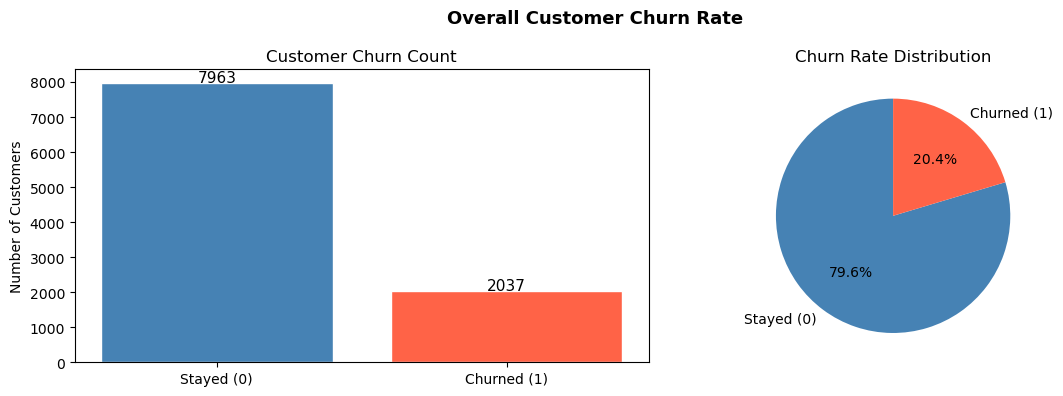

Churn rate: 20.4%


In [5]:
# --- Overall Churn Rate ---
churn_counts = df['Exited'].value_counts()
labels = ['Stayed (0)', 'Churned (1)']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(labels, churn_counts.values, color=['steelblue', 'tomato'], edgecolor='white')
axes[0].set_title('Customer Churn Count')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 30, f'{v}', ha='center', fontsize=11)

axes[1].pie(churn_counts.values, labels=labels, autopct='%1.1f%%',
            colors=['steelblue', 'tomato'], startangle=90)
axes[1].set_title('Churn Rate Distribution')

plt.suptitle('Overall Customer Churn Rate', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Churn rate: {churn_counts[1]/len(df):.1%}')

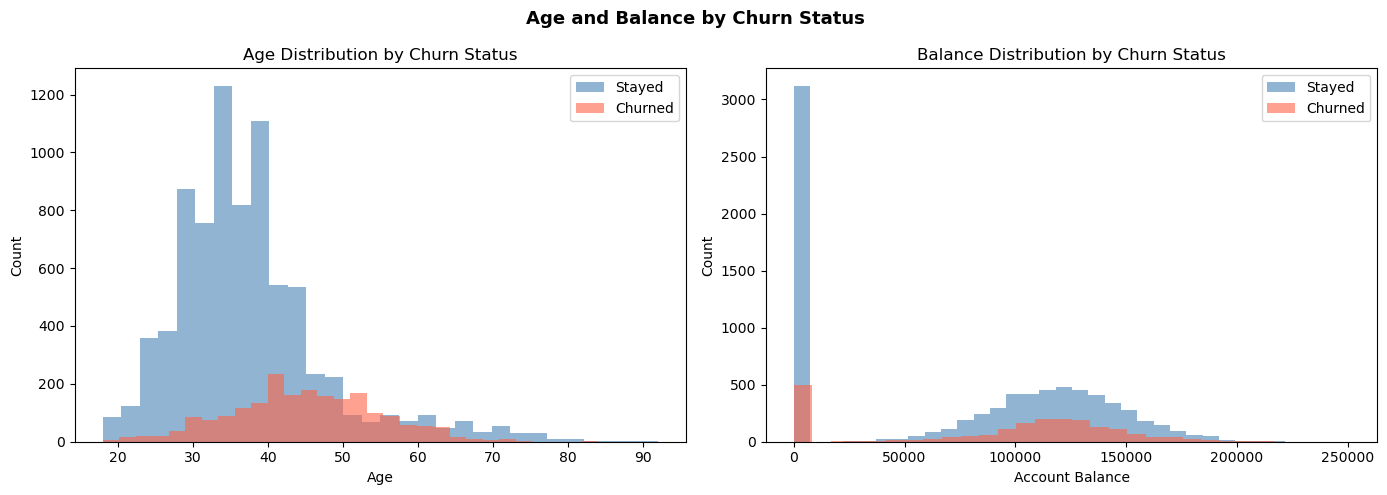

In [6]:
# --- Age & Balance Distribution by Churn Status ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for val, label, color in [(0, 'Stayed', 'steelblue'), (1, 'Churned', 'tomato')]:
    subset = df[df['Exited'] == val]
    axes[0].hist(subset['Age'], bins=30, alpha=0.6, label=label, color=color)
    axes[1].hist(subset['Balance'], bins=30, alpha=0.6, label=label, color=color)

axes[0].set_title('Age Distribution by Churn Status')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].set_title('Balance Distribution by Churn Status')
axes[1].set_xlabel('Account Balance')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.suptitle('Age and Balance by Churn Status', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

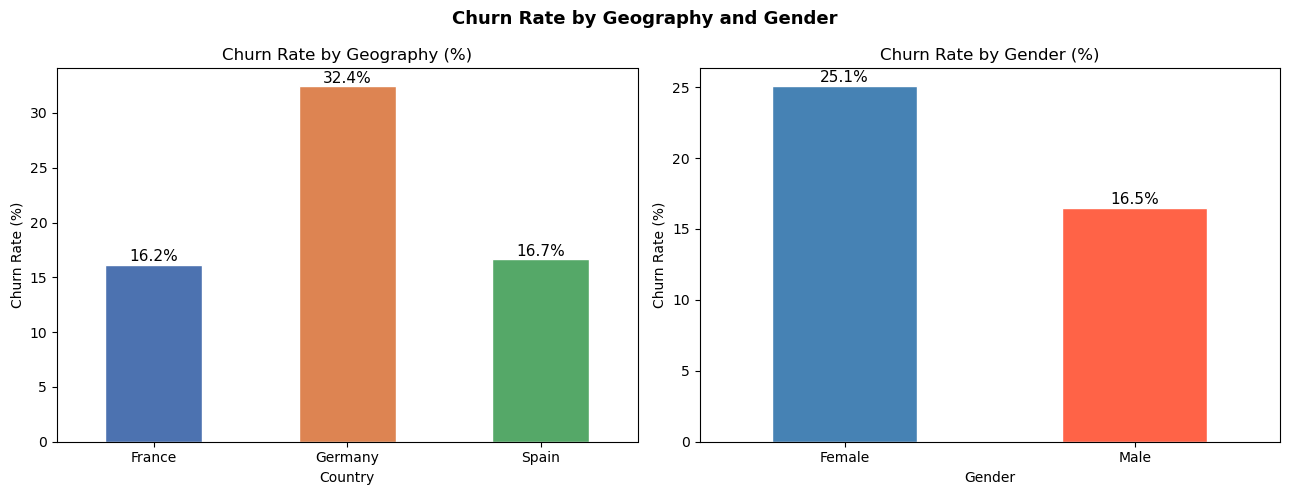

In [7]:
# --- Churn Rate by Geography and Gender ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Churn rate by Geography
geo_churn = df.groupby('Geography')['Exited'].mean() * 100
geo_churn.plot(kind='bar', ax=axes[0], color=['#4C72B0', '#DD8452', '#55A868'],
               edgecolor='white', rot=0)
axes[0].set_title('Churn Rate by Geography (%)')
axes[0].set_xlabel('Country')
axes[0].set_ylabel('Churn Rate (%)')
for i, v in enumerate(geo_churn):
    axes[0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=11)

# Churn rate by Gender
gen_churn = df.groupby('Gender')['Exited'].mean() * 100
gen_churn.plot(kind='bar', ax=axes[1], color=['steelblue', 'tomato'],
               edgecolor='white', rot=0)
axes[1].set_title('Churn Rate by Gender (%)')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Churn Rate (%)')
for i, v in enumerate(gen_churn):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=11)

plt.suptitle('Churn Rate by Geography and Gender', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

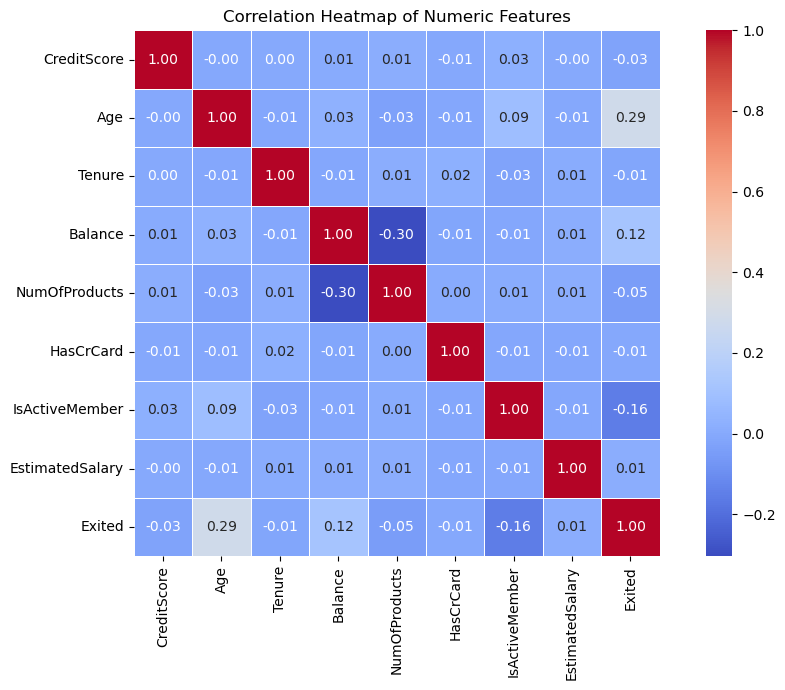

In [8]:
# --- Correlation Heatmap ---
plt.figure(figsize=(10, 7))
numeric_df = df.select_dtypes(include='number')
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.show()

## Step 5: Categorical Encoding

In [9]:
# Label Encoding — Gender (only 2 categories: Male=0, Female=1)
df['Gender_Encoded'] = (df['Gender'] == 'Female').astype(int)
print('Gender encoding: Female=1, Male=0')

# One-Hot Encoding — Geography (3 categories: France, Germany, Spain)
geo_dummies = pd.get_dummies(df['Geography'], prefix='Geo')
df = pd.concat([df, geo_dummies], axis=1)
print('Geography one-hot encoded:', geo_dummies.columns.tolist())

# Drop original text columns — now replaced by numeric encodings
df.drop(columns=['Geography', 'Gender'], inplace=True)

print('\nFinal columns:')
print(df.columns.tolist())

Gender encoding: Female=1, Male=0
Geography one-hot encoded: ['Geo_France', 'Geo_Germany', 'Geo_Spain']

Final columns:
['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Gender_Encoded', 'Geo_France', 'Geo_Germany', 'Geo_Spain']


## Step 6: Train-Test Split & Scaling

In [10]:
# Separate features (X) from target (y)
X = df.drop('Exited', axis=1)  # all columns except target
y = df['Exited']                # target: 1 = churned, 0 = stayed

# Split 80% train / 20% test
# stratify=y preserves the churn ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training samples: {X_train.shape[0]}')
print(f'Testing samples:  {X_test.shape[0]}')

# Scale: fit ONLY on train data, transform both sets
# This prevents data leakage from test into training
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

Training samples: 8000
Testing samples:  2000


## Step 7: Model Training

In [11]:
# --- Logistic Regression (needs scaled data) ---
lr = LogisticRegression(max_iter=500, random_state=42)
lr.fit(X_train_sc, y_train)
lr_pred  = lr.predict(X_test_sc)
lr_proba = lr.predict_proba(X_test_sc)[:, 1]

# --- Random Forest (works on raw data, ensemble of decision trees) ---
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
rf_pred  = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

# --- Gradient Boosting (sequential ensemble, often highest performance) ---
gb = GradientBoostingClassifier(n_estimators=200, random_state=42)
gb.fit(X_train, y_train)
gb_pred  = gb.predict(X_test)
gb_proba = gb.predict_proba(X_test)[:, 1]

print('All 3 models trained successfully!')

All 3 models trained successfully!


## Step 8: Evaluation Metrics

In [12]:
# Accuracy and ROC-AUC for all 3 models
models = [
    ('Logistic Regression', lr_pred, lr_proba),
    ('Random Forest',       rf_pred, rf_proba),
    ('Gradient Boosting',   gb_pred, gb_proba),
]

print(f'{"Model":<25} {"Accuracy":>10} {"ROC-AUC":>10}')
print('-' * 47)
for name, pred, proba in models:
    acc = accuracy_score(y_test, pred)
    roc = roc_auc_score(y_test, proba)
    print(f'{name:<25} {acc:>10.2%} {roc:>10.4f}')

Model                       Accuracy    ROC-AUC
-----------------------------------------------
Logistic Regression           80.80%     0.7748
Random Forest                 86.35%     0.8542
Gradient Boosting             86.75%     0.8694


In [13]:
# Full classification report for best model (Random Forest)
print('--- Random Forest: Classification Report ---')
print(classification_report(y_test, rf_pred, target_names=['Stayed', 'Churned']))

--- Random Forest: Classification Report ---
              precision    recall  f1-score   support

      Stayed       0.88      0.96      0.92      1593
     Churned       0.77      0.47      0.58       407

    accuracy                           0.86      2000
   macro avg       0.82      0.72      0.75      2000
weighted avg       0.86      0.86      0.85      2000



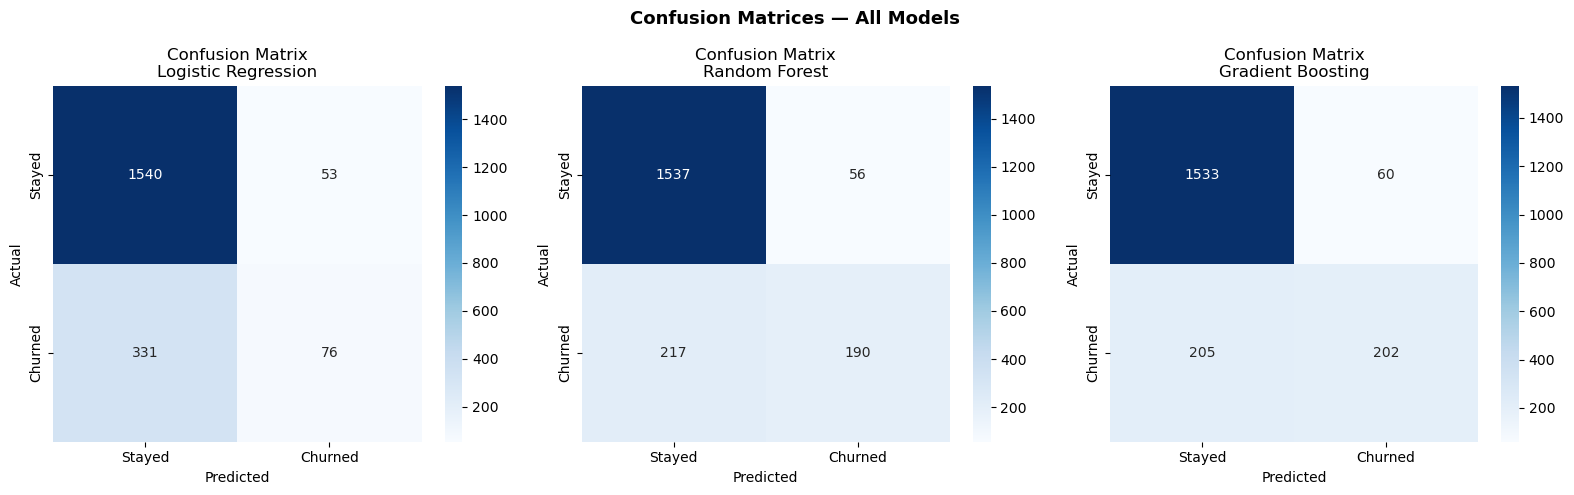

In [14]:
# --- Confusion Matrices for all 3 models ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, pred, _) in zip(axes, models):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Stayed', 'Churned'],
                yticklabels=['Stayed', 'Churned'])
    ax.set_title(f'Confusion Matrix\n{name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 9: Feature Importance Analysis

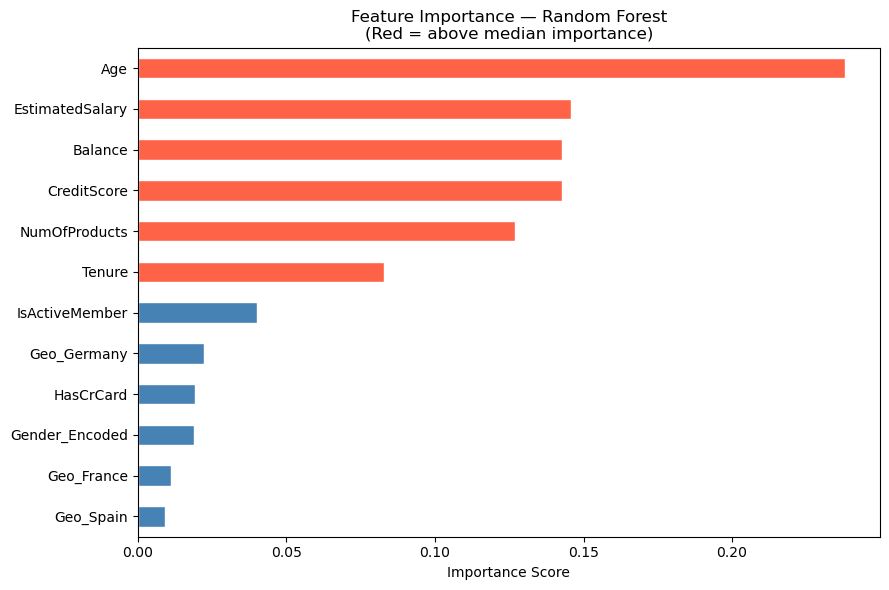

Top 5 most important features:
Age                0.237864
EstimatedSalary    0.145864
Balance            0.142853
CreditScore        0.142601
NumOfProducts      0.126902
dtype: float64


In [15]:
# Get feature importances from the trained Random Forest
importances = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=True)  # ascending for horizontal bar chart

plt.figure(figsize=(9, 6))
colors = ['tomato' if imp > importances.median() else 'steelblue' for imp in importances]
importances.plot(kind='barh', color=colors, edgecolor='white')
plt.title('Feature Importance — Random Forest\n(Red = above median importance)', fontsize=12)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('Top 5 most important features:')
print(importances.sort_values(ascending=False).head())

## Step 10: Conclusion

### Model Performance Summary

| Model | Accuracy | ROC-AUC |
|---|---|---|
| Logistic Regression | See output | See output |
| Random Forest | See output | See output |
| Gradient Boosting | See output | See output |

### Key Insights from EDA
1. **Germany** has a significantly higher churn rate compared to France and Spain.
2. **Female customers** churn at a higher rate than male customers.
3. **Older customers (40–60)** are more likely to churn than younger ones.
4. Customers with a **zero balance** rarely churn — high balance customers are at greater risk.

### Key Insights from Feature Importance
1. **Age** is the single most important predictor of churn.
2. **Number of Products** is highly important — customers with only 1 product are at higher churn risk.
3. **IsActiveMember** matters — inactive members are far more likely to leave.
4. **Balance** and **CreditScore** also contribute significantly.

### What I Learned
- Ensemble models (Random Forest, Gradient Boosting) outperform Logistic Regression on complex, non-linear customer behaviour data.
- Encoding categorical features correctly (Label vs One-Hot) prevents model errors.
- Feature importance analysis provides actionable business insights — the bank should focus retention efforts on older, inactive, single-product customers in Germany.